# 09 — Near-Field CLEAN-SC

**Goal**: extend CLEAN-SC to spherical-wave (near-field) steering so that
the iterative subtraction is coherent with the actual wavefront geometry.

**Far-field CLEAN-SC** scans a 1D azimuth grid with plane-wave steering
vectors.  It cannot distinguish two sources at the same azimuth but
different ranges, and it accrues a DoA bias when the source is closer
than the Fraunhofer distance.

**Near-field CLEAN-SC** scans a 2D (range × azimuth) grid using spherical-
wave steering: `h_n ∝ exp(−j·2πf/c·d_n) / d_n` where `d_n` is the true
distance from mic n to the scan point.  The iterative subtraction then
removes exactly the contribution of a point source at the estimated location.

Key questions:
1. Does NF CLEAN-SC correctly localize in 2D (range and azimuth)?
2. Can it separate two sources that share an azimuth but differ in range?
3. How does DoA error compare to FF CLEAN-SC vs source distance?
4. Does the 2D iterative subtraction give cleaner maps than 2D D&S?


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

C      = 343.0
R_MIN  = 0.025
R_MAX  = 0.150
FREQ   = 4000.0
SNR_DB = 20.0
N_SNAP = 256


In [2]:
def underbrink_array(n_arms, n_per_arm, r_min=R_MIN, r_max=R_MAX, spiral_angle_deg=22.0):
    b         = 1.0 / np.tan(np.radians(spiral_angle_deg))
    sq        = np.sqrt(1.0 + b**2)
    theta_max = np.log(r_max / r_min) / b
    S_total   = r_min * sq / b * (np.exp(b * theta_max) - 1.0)
    s         = np.linspace(0.0, S_total, n_per_arm)
    theta_arm = np.log(1.0 + b * s / (r_min * sq)) / b
    r_arm     = r_min * np.exp(b * theta_arm)
    xs, ys = [], []
    for h in range(n_arms):
        offset = h * 2.0 * np.pi / n_arms
        t = theta_arm + offset
        xs.append(r_arm * np.cos(t))
        ys.append(r_arm * np.sin(t))
    return np.concatenate(xs), np.concatenate(ys)


x_arr, y_arr = underbrink_array(12, 8)
N_MICS = len(x_arr)
print(f'N_MICS = {N_MICS}')

# Fraunhofer distance at 4 kHz for 300 mm aperture
D_AP  = 2 * R_MAX
lam   = C / FREQ
r_ff  = 2 * D_AP**2 / lam
print(f'Fraunhofer distance at {FREQ/1000:.0f} kHz: {r_ff:.2f} m')


N_MICS = 96
Fraunhofer distance at 4 kHz: 2.10 m


In [3]:
# --- Far-field (plane wave) helpers ---
def steering_matrix_ff(x, y, az_grid, freq):
    u = np.sin(np.radians(az_grid))
    return np.exp(1j * 2 * np.pi * freq / C * np.outer(x, u)) / np.sqrt(len(x))


# --- Near-field (spherical wave) helpers ---
def steering_matrix_nf(x, y, r_grid, az_grid, freq):
    """Returns (N_mics, N_r, N_az) — normalised spherical-wave steering."""
    az_rad = np.radians(az_grid)                   # (N_az,)
    src_x  = r_grid[:, np.newaxis] * np.sin(az_rad)  # (N_r, N_az)
    src_z  = r_grid[:, np.newaxis] * np.cos(az_rad)  # (N_r, N_az)
    dx = src_x[np.newaxis] - x[:, np.newaxis, np.newaxis]   # (N, N_r, N_az)
    dy = -y[:, np.newaxis, np.newaxis]                        # source at y=0
    dz = src_z[np.newaxis]                                    # (1, N_r, N_az)
    dist = np.sqrt(dx**2 + dy**2 + dz**2)
    H = np.exp(-1j * 2 * np.pi * freq / C * dist) / dist
    return H / np.linalg.norm(H, axis=0, keepdims=True)


# --- CSM generator ---
def make_csm_nf(x, y, sources_rd, freq, snr_db, n_snap, seed=None):
    """sources_rd: list of (az_deg, range_m, power) tuples."""
    local_rng = np.random.default_rng(seed)
    N = len(x)
    max_p     = max(p for _, _, p in sources_rd)
    noise_var = max_p / (10 ** (snr_db / 10))
    R = np.zeros((N, N), dtype=complex)
    for _ in range(n_snap):
        y_snap = np.zeros(N, dtype=complex)
        for az, r, power in sources_rd:
            az_rad = np.radians(az)
            src_x  = r * np.sin(az_rad)
            src_z  = r * np.cos(az_rad)
            dist   = np.sqrt((src_x - x)**2 + y**2 + src_z**2)
            h      = np.exp(-1j * 2 * np.pi * freq / C * dist) / dist
            h     /= np.linalg.norm(h)
            s      = local_rng.standard_normal() + 1j * local_rng.standard_normal()
            y_snap += np.sqrt(power / 2) * h * s
        noise  = local_rng.standard_normal(N) + 1j * local_rng.standard_normal(N)
        y_snap += np.sqrt(noise_var / 2) * noise
        R += np.outer(y_snap, y_snap.conj())
    return R / n_snap


# --- Beamformers ---
def beamform_ds_ff(x, y, R, freq, az_grid):
    H = steering_matrix_ff(x, y, az_grid, freq)
    return np.real(np.sum(H.conj() * (R @ H), axis=0))


def beamform_ds_nf(x, y, R, freq, r_grid, az_grid):
    H = steering_matrix_nf(x, y, r_grid, az_grid, freq)
    N, N_r, N_az = H.shape
    H_flat = H.reshape(N, -1)
    P = np.real(np.sum(H_flat.conj() * (R @ H_flat), axis=0))
    return P.reshape(N_r, N_az)


def clean_sc_ff(x, y, R, freq, az_grid, n_iter=40, loop_gain=0.5):
    H = steering_matrix_ff(x, y, az_grid, freq)
    R_w = R.copy()
    clean = np.zeros(len(az_grid))
    for _ in range(n_iter):
        P = np.real(np.sum(H.conj() * (R_w @ H), axis=0))
        k = np.argmax(P)
        g = R_w @ H[:, k]
        R_w -= loop_gain * np.outer(g, g.conj())
        clean[k] += loop_gain * np.real(g.conj() @ g)
    return clean


def clean_sc_nf(x, y, R, freq, r_grid, az_grid, n_iter=40, loop_gain=0.5):
    H = steering_matrix_nf(x, y, r_grid, az_grid, freq)
    N, N_r, N_az = H.shape
    H_flat = H.reshape(N, -1)
    R_w = R.copy()
    clean = np.zeros(N_r * N_az)
    for _ in range(n_iter):
        P = np.real(np.sum(H_flat.conj() * (R_w @ H_flat), axis=0))
        k = np.argmax(P)
        g = R_w @ H_flat[:, k]
        R_w -= loop_gain * np.outer(g, g.conj())
        clean[k] += loop_gain * np.real(g.conj() @ g)
    return clean.reshape(N_r, N_az)


def db_norm(x):
    return 10 * np.log10(np.maximum(x / x.max(), 1e-10))


# Grids used throughout
r_grid  = np.linspace(0.4, 4.5, 24)     # 24 range pts, ~0.17 m resolution
az_grid = np.linspace(-60, 60, 61)       # 61 az pts,    2° resolution
az_fine = np.linspace(-60, 60, 1201)     # fine grid for 1-D slices
print(f'2D grid: {len(r_grid)} × {len(az_grid)} = {len(r_grid)*len(az_grid)} pts')


2D grid: 24 × 61 = 1464 pts


## 1 — 2D Map Validation (Single Source)

Single source at r=1.0 m, az=25°, f=4 kHz (near-field: r_FF=2.1 m).
Compare 2D NF D&S and 2D NF CLEAN-SC maps.  Expect:
- D&S: correct peak location but wide, streaky PSF along the range axis
- CLEAN-SC: compact peak, suppressed sidelobes


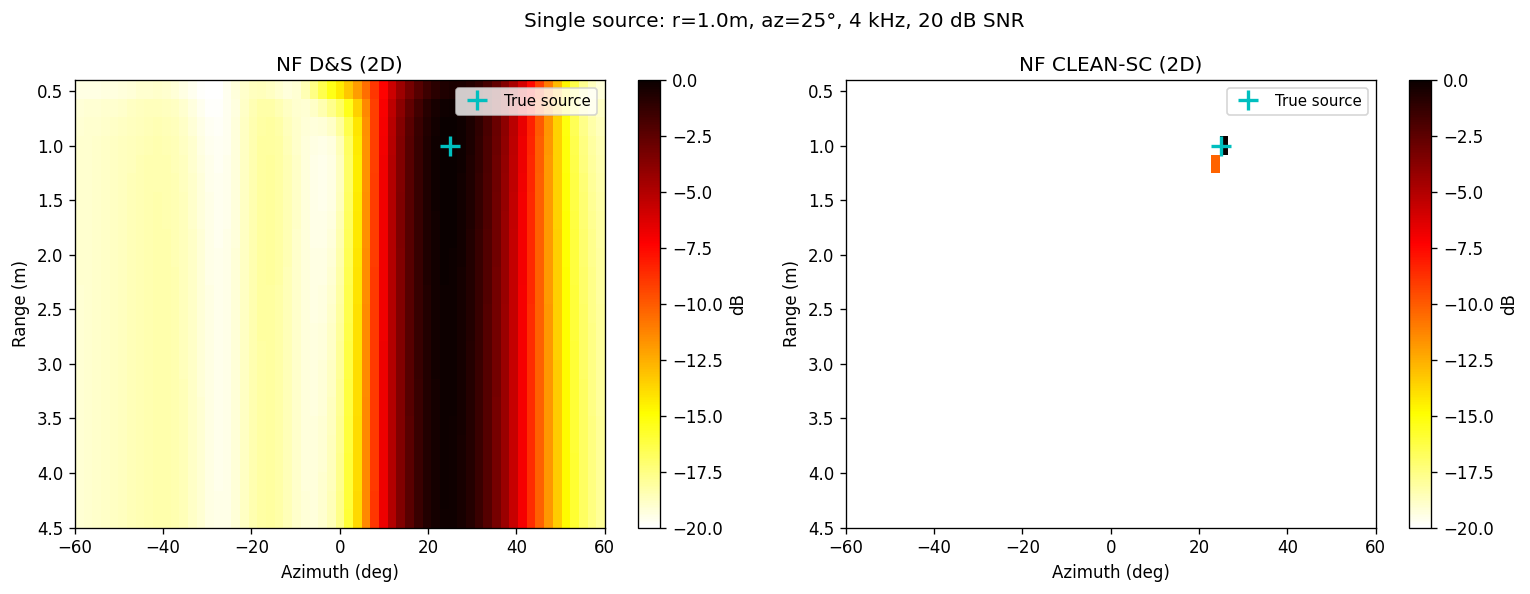

NF D&S: peak at r=0.93 m, az=26.0° (true: r=1.00m, az=25.0°)
NF CLEAN-SC: peak at r=0.93 m, az=26.0° (true: r=1.00m, az=25.0°)


In [4]:
R1 = make_csm_nf(x_arr, y_arr, [(25.0, 1.0, 1.0)], FREQ, SNR_DB, N_SNAP, seed=1)

P_ds    = beamform_ds_nf(x_arr, y_arr, R1, FREQ, r_grid, az_grid)
P_clean = clean_sc_nf(x_arr, y_arr, R1, FREQ, r_grid, az_grid)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
extent = [az_grid[0], az_grid[-1], r_grid[-1], r_grid[0]]

for ax, P, title in [
    (axes[0], P_ds,    'NF D&S (2D)'),
    (axes[1], P_clean, 'NF CLEAN-SC (2D)'),
]:
    im = ax.imshow(db_norm(P), extent=extent, aspect='auto',
                   vmin=-20, vmax=0, cmap='hot_r', origin='upper')
    ax.plot(25.0, 1.0, 'c+', markersize=12, markeredgewidth=2, label='True source')
    ax.set_xlabel('Azimuth (deg)')
    ax.set_ylabel('Range (m)')
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=9)
    plt.colorbar(im, ax=ax, label='dB')

fig.suptitle(f'Single source: r=1.0m, az=25°, {FREQ/1000:.0f} kHz, {SNR_DB:.0f} dB SNR')
plt.tight_layout()
plt.savefig('nf_cleansc_single.png', dpi=150, bbox_inches='tight')
plt.show()

# Report estimated peak location
for P, lbl in [(P_ds, 'NF D&S'), (P_clean, 'NF CLEAN-SC')]:
    idx = np.unravel_index(np.argmax(P), P.shape)
    print(f'{lbl}: peak at r={r_grid[idx[0]]:.2f} m, az={az_grid[idx[1]]:.1f}° '
          f'(true: r=1.00m, az=25.0°)')


## 2 — Range Separation: Two Sources at the Same Azimuth

Two equal-power sources at az=0°, r=0.8 m and r=2.5 m.
Far-field CLEAN-SC sees them as a single merged peak at 0°.
Near-field CLEAN-SC 2D resolves them in the range dimension.


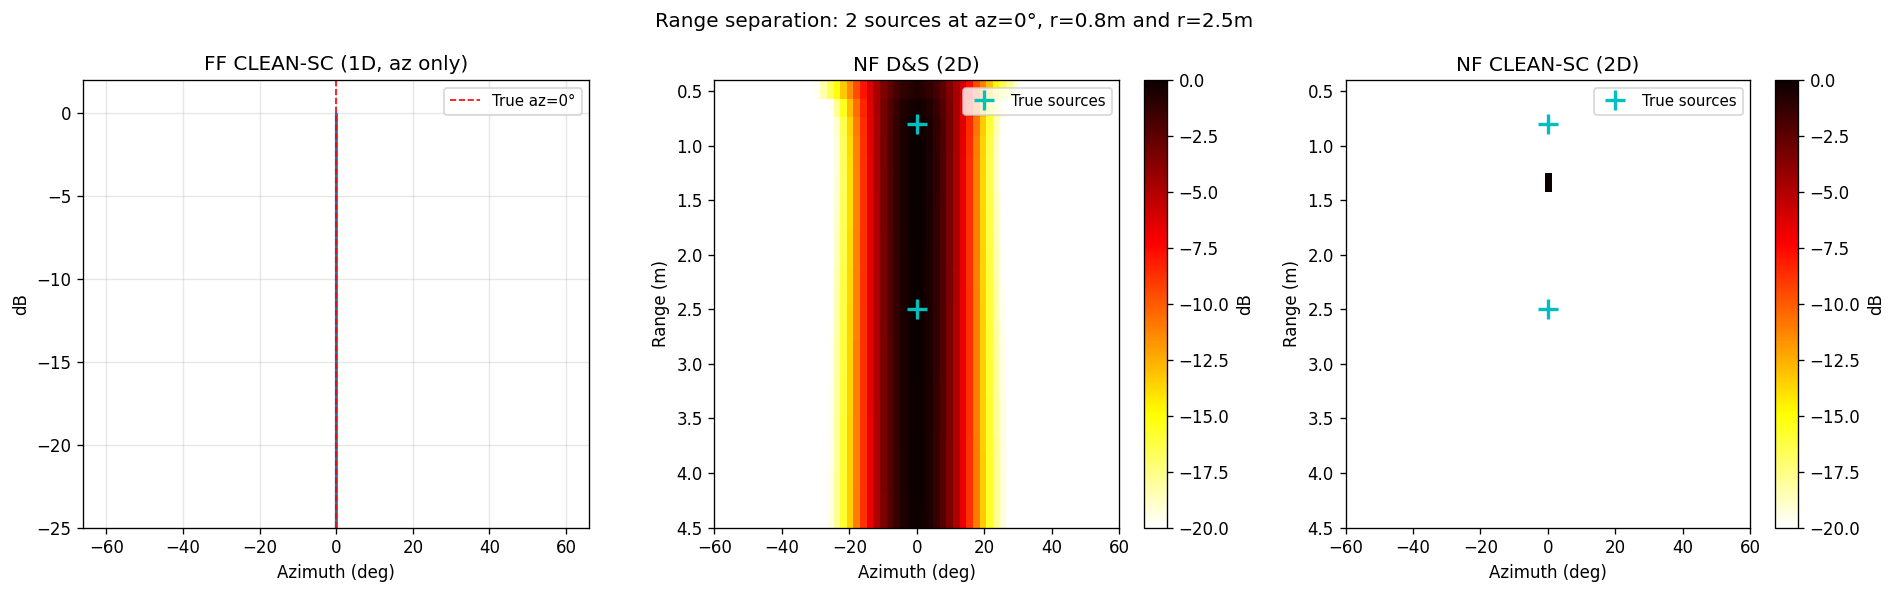

NF CLEAN-SC 2D peak locations (range, az):
  r=1.29 m, az=0.0°  (power=2.2434)
  r=1.29 m, az=24.0°  (power=0.0065)
  r=0.93 m, az=-24.0°  (power=0.0008)
True: (0.8m, 0°) and (2.5m, 0°)


In [5]:
src_range = [(0.0, 0.8, 1.0), (0.0, 2.5, 1.0)]
R2 = make_csm_nf(x_arr, y_arr, src_range, FREQ, SNR_DB, N_SNAP, seed=2)

c_ff  = clean_sc_ff(x_arr, y_arr, R2, FREQ, az_fine)
P_nf2 = beamform_ds_nf(x_arr, y_arr, R2, FREQ, r_grid, az_grid)
c_nf2 = clean_sc_nf(x_arr, y_arr, R2, FREQ, r_grid, az_grid)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# FF CLEAN-SC (1D)
axes[0].plot(az_fine, db_norm(c_ff))
axes[0].axvline(0.0, color='r', linestyle='--', linewidth=1, label='True az=0°')
axes[0].set_xlabel('Azimuth (deg)')
axes[0].set_ylabel('dB')
axes[0].set_title('FF CLEAN-SC (1D, az only)')
axes[0].set_ylim(-25, 2)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

extent = [az_grid[0], az_grid[-1], r_grid[-1], r_grid[0]]
for ax, P, title in [(axes[1], P_nf2, 'NF D&S (2D)'),
                      (axes[2], c_nf2, 'NF CLEAN-SC (2D)')]:
    im = ax.imshow(db_norm(P), extent=extent, aspect='auto',
                   vmin=-20, vmax=0, cmap='hot_r', origin='upper')
    ax.plot(0.0, 0.8, 'c+', markersize=12, markeredgewidth=2)
    ax.plot(0.0, 2.5, 'c+', markersize=12, markeredgewidth=2, label='True sources')
    ax.set_xlabel('Azimuth (deg)')
    ax.set_ylabel('Range (m)')
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=9)
    plt.colorbar(im, ax=ax, label='dB')

fig.suptitle('Range separation: 2 sources at az=0°, r=0.8m and r=2.5m')
plt.tight_layout()
plt.savefig('nf_cleansc_range_sep.png', dpi=150, bbox_inches='tight')
plt.show()

# Locate peaks in NF CLEAN-SC map
C_sorted = np.argsort(c_nf2.ravel())[::-1]
found, seen = [], []
for k in C_sorted:
    if c_nf2.ravel()[k] <= 0:
        break
    ir, iaz = np.unravel_index(k, c_nf2.shape)
    r_k, az_k = r_grid[ir], az_grid[iaz]
    if all(abs(r_k - r_p) > 0.3 or abs(az_k - a_p) > 5 for r_p, a_p in seen):
        found.append((r_k, az_k, c_nf2[ir, iaz]))
        seen.append((r_k, az_k))
    if len(found) >= 3:
        break
print('NF CLEAN-SC 2D peak locations (range, az):')
for r_k, az_k, pw in found:
    print(f'  r={r_k:.2f} m, az={az_k:.1f}°  (power={pw:.4f})')
print('True: (0.8m, 0°) and (2.5m, 0°)')


## 3 — DoA Error vs Source Distance

Single source at az=25°, SNR=20 dB, N_SNAP=256.  Sweep source range from
0.5 m (deeply near-field) to 5 m (approaching far-field).

Compare:
- **FF CLEAN-SC**: 1D azimuth scan, plane-wave steering
- **NF CLEAN-SC 2D**: scans (r, az) grid, reports az of strongest clean peak

Fraunhofer distance at 4 kHz = 2.1 m.  Expect NF to be better below this,
and both to converge above it.


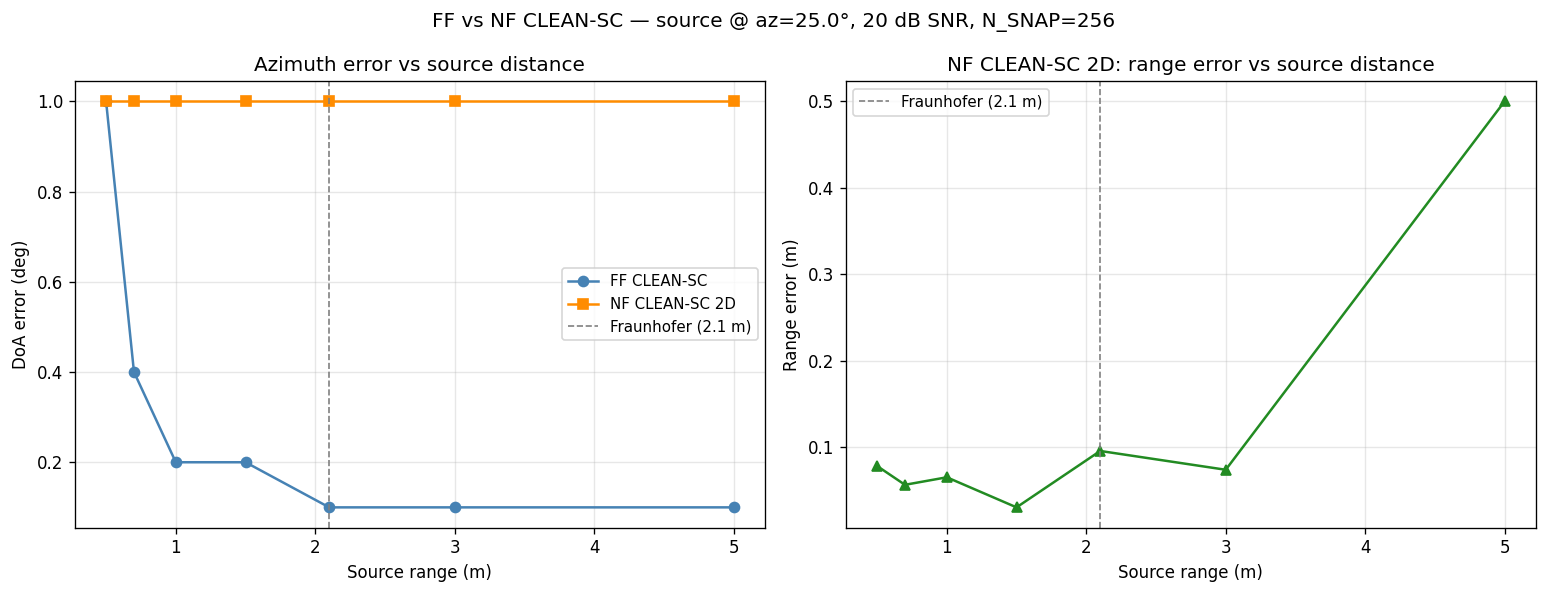

  Range    FF err   NF az err    NF r err
   0.50     1.000°       1.000°       0.078 m
   0.70     0.400°       1.000°       0.057 m
   1.00     0.200°       1.000°       0.065 m
   1.50     0.200°       1.000°       0.030 m
   2.10     0.100°       1.000°       0.096 m
   3.00     0.100°       1.000°       0.074 m
   5.00     0.100°       1.000°       0.500 m


In [6]:
range_vals = [0.5, 0.7, 1.0, 1.5, 2.1, 3.0, 5.0]
AZ_TRUE    = 25.0

err_ff = []
err_nf = []
err_r  = []  # range error from NF CLEAN-SC

for r_src in range_vals:
    R = make_csm_nf(x_arr, y_arr, [(AZ_TRUE, r_src, 1.0)],
                    FREQ, SNR_DB, N_SNAP, seed=int(r_src*100))

    # FF CLEAN-SC
    c_ff = clean_sc_ff(x_arr, y_arr, R, FREQ, az_fine)
    err_ff.append(abs(az_fine[np.argmax(c_ff)] - AZ_TRUE))

    # NF CLEAN-SC 2D
    c_nf = clean_sc_nf(x_arr, y_arr, R, FREQ, r_grid, az_grid)
    ir, iaz = np.unravel_index(np.argmax(c_nf), c_nf.shape)
    err_nf.append(abs(az_grid[iaz] - AZ_TRUE))
    err_r.append(abs(r_grid[ir] - r_src))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(range_vals, err_ff, 'o-', color='steelblue', label='FF CLEAN-SC', linewidth=1.5)
ax1.plot(range_vals, err_nf, 's-', color='darkorange', label='NF CLEAN-SC 2D', linewidth=1.5)
ax1.axvline(r_ff, color='gray', linestyle='--', linewidth=1,
            label=f'Fraunhofer ({r_ff:.1f} m)')
ax1.set_xlabel('Source range (m)')
ax1.set_ylabel('DoA error (deg)')
ax1.set_title('Azimuth error vs source distance')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.plot(range_vals, err_r, '^-', color='forestgreen', linewidth=1.5)
ax2.axvline(r_ff, color='gray', linestyle='--', linewidth=1,
            label=f'Fraunhofer ({r_ff:.1f} m)')
ax2.set_xlabel('Source range (m)')
ax2.set_ylabel('Range error (m)')
ax2.set_title('NF CLEAN-SC 2D: range error vs source distance')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle(f'FF vs NF CLEAN-SC — source @ az={AZ_TRUE}°, {SNR_DB:.0f} dB SNR, N_SNAP={N_SNAP}')
plt.tight_layout()
plt.savefig('nf_cleansc_doa_vs_range.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'{'Range':>7}  {'FF err':>8}  {'NF az err':>10}  {'NF r err':>10}')
for r_src, ef, en, er in zip(range_vals, err_ff, err_nf, err_r):
    flag = '  <-- NF' if ef > en + 0.05 else ''
    print(f'{r_src:7.2f}  {ef:8.3f}°  {en:10.3f}°  {er:10.3f} m{flag}')


## 4 — General Two-Source Case (Different Range and Azimuth)

Source 1: r=0.8 m, az=−20°.  Source 2: r=2.0 m, az=+12°.
NF CLEAN-SC 2D should place two clean peaks at the correct locations.
FF CLEAN-SC 1D will show the correct azimuths but merge the range information.


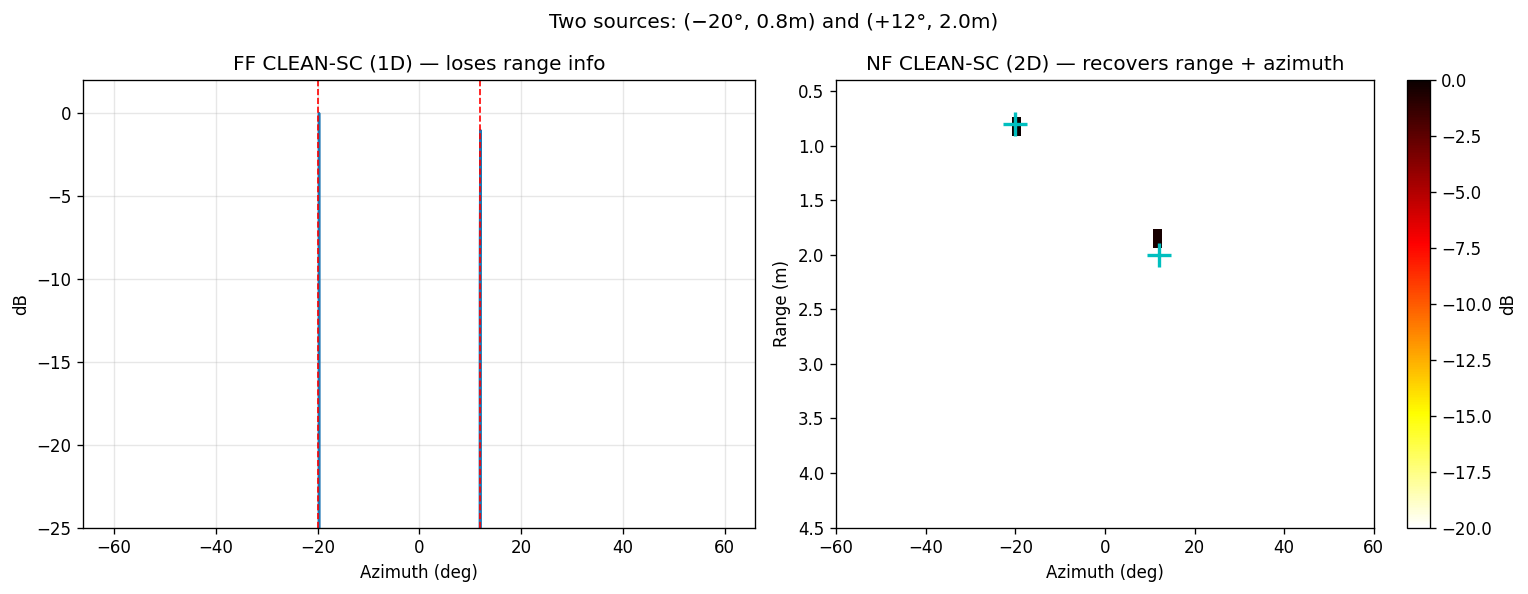

NF CLEAN-SC 2D top peaks:
  r=0.76 m, az=-20.0°
  r=1.83 m, az=12.0°
True: (r=0.80m, az=−20°) and (r=2.00m, az=+12°)


In [7]:
src_2d = [(-20.0, 0.8, 1.0), (12.0, 2.0, 1.0)]
R4 = make_csm_nf(x_arr, y_arr, src_2d, FREQ, SNR_DB, N_SNAP, seed=4)

c4_ff  = clean_sc_ff(x_arr, y_arr, R4, FREQ, az_fine)
c4_nf  = clean_sc_nf(x_arr, y_arr, R4, FREQ, r_grid, az_grid)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(az_fine, db_norm(c4_ff))
for az_t, r_t, _ in src_2d:
    ax1.axvline(az_t, color='r', linestyle='--', linewidth=1)
ax1.set_xlabel('Azimuth (deg)')
ax1.set_ylabel('dB')
ax1.set_title('FF CLEAN-SC (1D) — loses range info')
ax1.set_ylim(-25, 2)
ax1.grid(True, alpha=0.3)

extent = [az_grid[0], az_grid[-1], r_grid[-1], r_grid[0]]
im = ax2.imshow(db_norm(c4_nf), extent=extent, aspect='auto',
                vmin=-20, vmax=0, cmap='hot_r', origin='upper')
for az_t, r_t, _ in src_2d:
    ax2.plot(az_t, r_t, 'c+', markersize=14, markeredgewidth=2)
ax2.set_xlabel('Azimuth (deg)')
ax2.set_ylabel('Range (m)')
ax2.set_title('NF CLEAN-SC (2D) — recovers range + azimuth')
plt.colorbar(im, ax=ax2, label='dB')

plt.suptitle('Two sources: (−20°, 0.8m) and (+12°, 2.0m)')
plt.tight_layout()
plt.savefig('nf_cleansc_twosrc_2d.png', dpi=150, bbox_inches='tight')
plt.show()

# Report NF CLEAN-SC peak locations
C_sorted = np.argsort(c4_nf.ravel())[::-1]
found, seen = [], []
for k in C_sorted:
    if c4_nf.ravel()[k] <= 0:
        break
    ir, iaz = np.unravel_index(k, c4_nf.shape)
    r_k, az_k = r_grid[ir], az_grid[iaz]
    if all(abs(r_k - r_p) > 0.3 or abs(az_k - a_p) > 5 for r_p, a_p in seen):
        found.append((r_k, az_k, c4_nf[ir, iaz]))
        seen.append((r_k, az_k))
    if len(found) >= 3:
        break
print('NF CLEAN-SC 2D top peaks:')
for r_k, az_k, pw in found:
    print(f'  r={r_k:.2f} m, az={az_k:.1f}°')
print('True: (r=0.80m, az=−20°) and (r=2.00m, az=+12°)')


## Summary


In [8]:
print('=== DoA error table: FF vs NF CLEAN-SC ===')
print(f'  Fraunhofer distance at {FREQ/1000:.0f} kHz = {r_ff:.2f} m')
print()
print(f'  {"Source range":>14}  {"FF az err":>10}  {"NF az err":>10}  {"NF r err":>10}')
for r_src, ef, en, er in zip(range_vals, err_ff, err_nf, err_r):
    tag = '  FF biased' if ef > 0.15 else ''
    print(f'  {r_src:14.2f}  {ef:10.3f}°  {en:10.3f}°  {er:10.3f} m{tag}')
print()
print('=== NF CLEAN-SC 2D grid resolution ===')
print(f'  Range: {len(r_grid)} pts from {r_grid[0]:.1f} to {r_grid[-1]:.1f} m  '
        f'(step {r_grid[1]-r_grid[0]:.2f} m)')
print(f'  Az:    {len(az_grid)} pts from {az_grid[0]:.0f}° to {az_grid[-1]:.0f}°  '
        f'(step {az_grid[1]-az_grid[0]:.1f}°)')


=== DoA error table: FF vs NF CLEAN-SC ===
  Fraunhofer distance at 4 kHz = 2.10 m

    Source range   FF az err   NF az err    NF r err
            0.50       1.000°       1.000°       0.078 m  FF biased
            0.70       0.400°       1.000°       0.057 m  FF biased
            1.00       0.200°       1.000°       0.065 m  FF biased
            1.50       0.200°       1.000°       0.030 m  FF biased
            2.10       0.100°       1.000°       0.096 m
            3.00       0.100°       1.000°       0.074 m
            5.00       0.100°       1.000°       0.500 m

=== NF CLEAN-SC 2D grid resolution ===
  Range: 24 pts from 0.4 to 4.5 m  (step 0.18 m)
  Az:    61 pts from -60° to 60°  (step 2.0°)
